# Assignment 2: SLCM Regression Analysis
**CS-430-01 Machine Learning | Programming Assignments**


## Goal
The purpose of this assignment is to apply the regression techniques we have studied to a real community dataset. You will prepare numerical and categorical variables for machine learning, build several regression models, compare their performance, and interpret what the results mean.

The prediction question for this assignment is:

> Can household, income, employment, and housing-related information help predict the amount of past-due rent?

You will use `past_due_rent` as the target variable.

You will compare:
- Multiple Linear Regression
- Polynomial Regression
- Ridge Regression
- Lasso Regression

The goal is not simply to find the model with the highest score. You should think about how the models behave, whether additional complexity improves prediction, and what the results mean in the context of SLCM's work.

## Notebook Instructions
- Copy each numbered question below into a Markdown cell before answering it.
- Use a code cell directly below the Markdown question when code is needed.
- After important outputs and every visualization, add a short Markdown interpretation in your own words.
- Keep useful outputs visible in the submitted notebook.
- Use `random_state=42` when splitting the data.
- Use the same training and testing data when comparing models.
- Use pipelines where appropriate so preprocessing and modeling are performed together.

## Setup

In [57]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score

In [58]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Part 1 – Get to Know the Prediction Problem (15 points)

### 1. Load the dataset and examine its structure.
- Load the CSV file into pandas.
- Display the first 5 rows.

In [59]:
# Q1 code
df = pd.read_csv("SLCM_rent_arrears_student_clean.csv")
df.head()

,record_id,adults_in_household,children_in_household,household_has_65plus,monthly_household_income,income_sources,employment_status,has_housing_voucher,eviction_in_progress,behind_on_utilities,main_reason_behind_on_rent,intake_quarter,monthly_rent,past_due_rent
0,SLCM_0001,1,1,No,293.0,"Food benefits - TANF/SNAP, No income, Other",Unemployed but want to find work,No,I don't know,Yes,Other,2026-Q1,1560.0,3100.0
1,SLCM_0002,0,3,No,2000.0,Child support,Employed,No,I don't know,Yes,Unexpected expense,2026-Q3,1550.0,7300.0
2,SLCM_0003,1,0,No,400.0,Food benefits - TANF/SNAP,Unemployed but want to find work,I don't know,Yes,Yes,Lost a job/had hours cut,2025-Q4,0.0,6000.0
3,SLCM_0004,2,0,No,2500.0,Full-time employment,Unemployed and not looking for work,No,Yes,Yes,Lost a job/had hours cut,2026-Q2,1299.0,2500.0
4,SLCM_0005,1,2,No,14.0,Part-time employment,Employed,No,Yes,No,Unexpected expense,2025-Q4,1105.5,1205.5


- Report the number of rows and columns.  
1754 rows, 14 columns

In [60]:
df.shape

(1754, 14)

- Print the column names.


In [61]:
df.columns

Index(['record_id', 'adults_in_household', 'children_in_household',
       'household_has_65plus', 'monthly_household_income', 'income_sources',
       'employment_status', 'has_housing_voucher', 'eviction_in_progress',
       'behind_on_utilities', 'main_reason_behind_on_rent', 'intake_quarter',
       'monthly_rent', 'past_due_rent'],
      dtype='object')

- Use `info()` to inspect the dataset.

In [62]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1754 entries, 0 to 1753
Data columns (total 14 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   record_id                   1754 non-null   object 
 1   adults_in_household         1754 non-null   int64  
 2   children_in_household       1754 non-null   int64  
 3   household_has_65plus        1754 non-null   object 
 4   monthly_household_income    1646 non-null   float64
 5   income_sources              1754 non-null   object 
 6   employment_status           1754 non-null   object 
 7   has_housing_voucher         1754 non-null   object 
 8   eviction_in_progress        1753 non-null   object 
 9   behind_on_utilities         1747 non-null   object 
 10  main_reason_behind_on_rent  1738 non-null   object 
 11  intake_quarter              1754 non-null   object 
 12  monthly_rent                1746 non-null   float64
 13  past_due_rent               1754 

**Answer:**
- Which variable will be the target? `past_due_rent`
- Which columns appear to be numerical? `adults_int_household`, `children_in_household`, `monthly_household_income`,`monthly_rent`,`past_due_rent`
- Which columns appear to be categorical?`record_id`, `household_has_65plus`, `income_sources`,`employment_status`, `has_housing_voucher`,`eviction_in_progress`,`behind_on_utilities`, `main_reason_behind_on_rent`, `intake_quarter`

### 2. Investigate missing values.
- Calculate the number of missing values in every column.  
140 total missing values
- Identify which variables contain missing data.  
`monthly_household_income`, `eviction_in_progress`, `behind_on_utilities`, `main_reason_behind_on_rent`, and `monthly_rent`

In [63]:
# count all null values
df.isnull().sum()

,0
record_id,0
adults_in_household,0
children_in_household,0
household_has_65plus,0
monthly_household_income,108
income_sources,0
employment_status,0
has_housing_voucher,0
eviction_in_progress,1
behind_on_utilities,7


- Briefly describe how you plan to handle those missing values before modeling.

I plan to use the median to fill in missing `monthly_household_income` and `monthly_rent` values, and for the remaining categorical columns with missing values i will add a new value called 'Missing' and fill in that option.  
I'm choosing to do this because choosing the most common category option to fill in null values may skew results.

### 3. Explore the target variable: `past_due_rent`.
Calculate:
- count 1754
- mean 2404
- median 2000
- standard deviation 2089
- minimum 0
- maximum 1050



In [64]:
df['past_due_rent'].describe()

,past_due_rent
count,1754.000000
mean,2408.006933
std,2089.515372
min,0.000000
25%,1050.000000
50%,2000.000000
75%,3200.000000
max,20000.000000


In [65]:
df['past_due_rent'].median()

2000.0

Create:
- a histogram
- a boxplot

<Axes: xlabel='past_due_rent', ylabel='Count'>

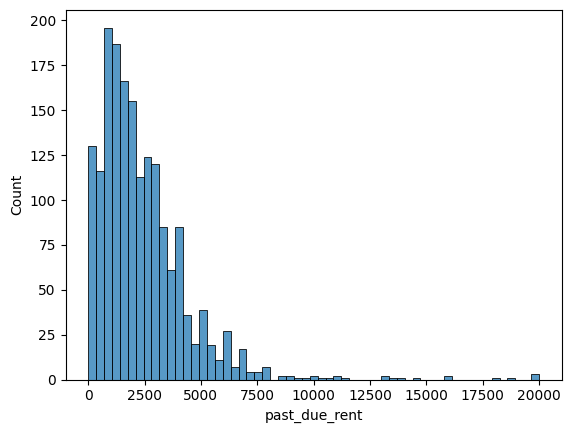

In [66]:
sns.histplot(df['past_due_rent'])

<Axes: ylabel='past_due_rent'>

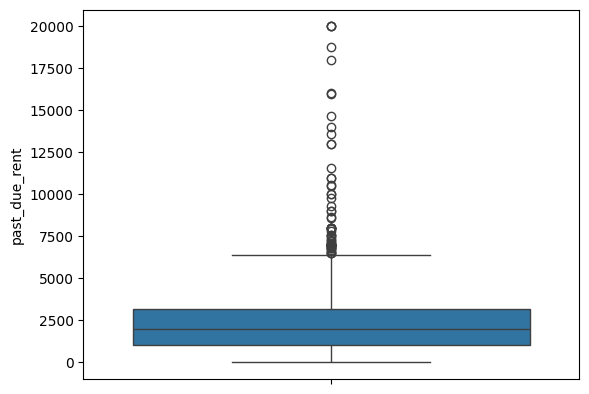

In [67]:
sns.boxplot(df['past_due_rent'])

In [68]:
# print mean and median values for the column
print("Mean: ", df['past_due_rent'].mean())
print("Median: ", df['past_due_rent'].median())

Mean:  2408.0069327251995
Median:  2000.0


- What does the distribution look like? Is the distribution symmetric or skewed?  
The distribution looks rightly skewed as most of the values are on the left side of the chart
- Are the mean and median similar?  
Sort of. The mean is ~2400 and the median is 2000, those numbers sound far apart but seeing as we have values in the 7500-15000 range as well we are actually relatively close together.
- Do you notice any unusually high values?  
No. I can't say for certain that any of those high values are truly unusual as its not like we have a single data point absurdly higher than the rest, instead what we see is a continuous stream of 1-2 occurances of the higher data values. And this makes sense as the higher values would naturally be less common too
- Why might rent-arrears data naturally contain a wide range of values?  
The data is going to contain a wide range of values because the data is being gathered over a full city (and some data points outside the city) so it makes sense that we get a range of values semi-proportionate to what is actually found in the city.

# Part 2 – Prepare the Data for Machine Learning (25 points)

### 4. Create your input features and target.
Create `X` and `y` using `past_due_rent` as the target. Do not use `record_id` as an input feature.

**Answer:**
- Why should `record_id` not be used to predict past-due rent?  
Because an id number has no bearing on how much rent someone has past due, its a generated backend identifier number.

In [69]:
X = df.drop(columns=['record_id', 'past_due_rent'])
y = df['past_due_rent']

### 5. Separate the numerical and categorical features.
- Create lists containing numerical features and categorical features.
- Display both lists.
- Briefly explain why machine-learning models require different preparation steps for numerical and categorical variables.  
we use different preparation steps because we have different tools at our disposal. For numerical data we have the ability to take means and meadians to estiamte missing values, and with categorical values to allow a model to learn the different categories we can create on hot encoded columns, one to represent each possible choice.

In [70]:
numerical_features = ['adults_in_household', 'children_in_household', 'monthly_household_income', 'monthly_rent']
categorical_features = ['household_has_65plus', 'income_sources', 'employment_status', 'has_housing_voucher', 'eviction_in_progress', 'behind_on_utilities', 'main_reason_behind_on_rent', 'intake_quarter']
print(numerical_features)
print(categorical_features)

['adults_in_household', 'children_in_household', 'monthly_household_income', 'monthly_rent']
['household_has_65plus', 'income_sources', 'employment_status', 'has_housing_voucher', 'eviction_in_progress', 'behind_on_utilities', 'main_reason_behind_on_rent', 'intake_quarter']


### 6. Split the data into training and testing sets.
Use `test_size=0.20` and `random_state=42`.
- Report the dimensions of `X_train`, `X_test`, `y_train`, and `y_test`.  
`X_train` (1403, 12)  
`X_test`(351, 12)  
`y_train`(1403,)  
`y_test`(351,)  
- Why should the model be evaluated using data that was not used during training?  
Because if the model overfit to the training data it will perfectly predict the values when we run it through the model again, but perform horribly with any new data values.

In [71]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(1403, 12)
(351, 12)
(1403,)
(351,)


### 7. Prepare the numerical variables.
Create an appropriate numerical preprocessing pipeline. Your pipeline should consider missing values and feature scaling. Use appropriate tools such as `SimpleImputer` and `StandardScaler`.

**Explain:**
- How did you handle missing numerical values?  
I used the median
- Why might feature scaling matter when comparing Linear, Ridge, and Lasso models?  
Ridge and lasso use penalty scores which will affect different ranges of numbesr differently, so to get a more accurate result StandardScaler is used to ensure all columns occupy the same number range during training and are impacted by the penalty amounts equivalently

In [72]:
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

### 8. Prepare the categorical variables.
Create an appropriate categorical preprocessing pipeline. Your pipeline should consider missing values and converting text categories into numerical values. Use appropriate tools such as `SimpleImputer` and `OneHotEncoder`.

**Answer:**
- Why can the regression models not directly use values such as employment categories?  
Because the model looks for numerical values and it doesnt know how to interpret characters.
- Why is one-hot encoding appropriate for these variables?  
Because each row can have exclusively 1 of the possible options not multiple.
- Why would assigning arbitrary numbers such as 1, 2, 3, and 4 to unordered categories potentially be misleading?  
Because non of the categories are necessarily "bigger" than the others, which using 1-4 would imply to a regression model.

In [73]:
categorial_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='Missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

### 9. Combine your preprocessing steps.
Use a `ColumnTransformer` to combine the numerical and categorical preprocessing. Your preprocessing should be reusable inside the regression pipelines you create in the next part.

Explain briefly why using a preprocessing pipeline is useful.  
So that we dont have to rewrite the same steps each time, and it ensures all models go through the exact same preprocessing steps before training.

In [74]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorial_transformer, categorical_features)
    ])

# Part 3 – Build and Compare Regression Models (45 points)

### 10. Build a Multiple Linear Regression model.
Create a pipeline containing your preprocessing and a Linear Regression model. Train the model using the training data and make predictions for the testing data.


In [75]:
from sklearn import linear_model
linear_model = Pipeline(steps=[('preprocessor', preprocessor),
                              ('regressor', linear_model.LinearRegression())])
linear_model.fit(X_train, y_train)
y_pred = linear_model.predict(X_test)

Calculate:
- RMSE 1851
- R² 0.1638

In [76]:
linear_mse = mean_squared_error(y_test, y_pred)
linear_rmse = np.sqrt(linear_mse)
linear_r2 = r2_score(y_test, y_pred)
print("RMSE: ", linear_rmse)
print("R2: ", linear_r2)

RMSE:  1851.4308561805178
R2:  0.16376545089084582


Create an Actual vs. Predicted scatterplot with actual values on the x-axis, predicted values on the y-axis, and a diagonal reference line showing where perfect predictions would fall.

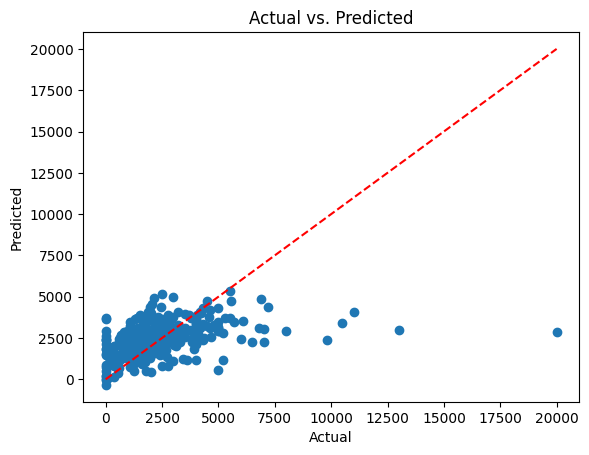

In [77]:
# create the plot
plt.scatter(y_test, y_pred)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Actual vs. Predicted')

# add the diagonal reference line
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'r--')
plt.show()

**Answer:**
- What does RMSE represent in this problem?  
RMSE is how far off the models average guess was
- What does the R² score tell you?  
R2 score describes what proportion of the data the model accurately describes
- Based on the graph, how closely do the predictions match the actual values?  
Not very closely at all
- Do you notice cases where the model makes large prediction errors?  
The few higher values we have were totally inaccurately captured. Its possible not having them would overall help the model even if it made it predict the less common higher values worse.

### 11. Build a Polynomial Regression model.
Real-world relationships are not always perfectly linear. For this model, use `PolynomialFeatures(degree=2, include_bias=False)`. Apply polynomial transformation to the appropriate numerical variables. Do not automatically apply polynomial expansion to all one-hot encoded categorical variables.


In [78]:
# A more streamlined and concise way to define the same pipeline:
poly_preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler()),
            ('poly', PolynomialFeatures(degree=2, include_bias=False))
        ]), numerical_features),
        ('cat', categorial_transformer, categorical_features)
    ]
)

# Combine preprocessor with Linear Regression
poly_model = Pipeline([
    ('preprocessor', poly_preprocessor),
    ('regressor', LinearRegression())
])

# Train the model
poly_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler()),
                                                                  ('poly',
                                                                   PolynomialFeatures(include_bias=False))]),
                                                  ['adults_in_household',
                                                   'children_in_household',
                                                   'monthly_household_income',
                                                   'monthly_rent']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='Missing',
                                                                                 strategy='constant')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['household_has_65plus',
                                                   'income_sources',
                                                   'employment_status',
                                                   'has_housing_voucher',
                                                   'eviction_in_progress',
                                                   'behind_on_utilities',
                                                   'main_reason_behind_on_rent',
                                                   'intake_quarter'])])),
                ('regressor', LinearRegression())])

Train the model and calculate RMSE and R².


In [79]:
poly_model_pred = poly_model.predict(X_test)
poly_mse = mean_squared_error(y_test, poly_model_pred)
poly_rmse = np.sqrt(poly_mse)
poly_r2 = r2_score(y_test, poly_model_pred)
print("RMSE: ", poly_rmse)
print("R2: ", poly_r2)

RMSE:  1863.4496890335147
R2:  0.15287313418878468


**Answer:**
- Did Polynomial Regression perform better or worse than Linear Regression?  
Worse, the average prediction is off by a slightly higher amount and the r2 score indicates we're correctly predicting a smaller percentage of our training data.
- What does a degree-2 polynomial allow the model to represent that Linear Regression cannot?  
Non-linear relationships. In basic linear regression you're doing regression on the coefficients of variables to the power of 1 only, in degree-2 polynomials with linear regression you also have coefficients of squared variables which allows the resulting curve to fit non linear relationships.
- Why could using a very high polynomial degree lead to overfitting?  
Since this resulting regression line can be curved, it is possible for large coefficent values to allow this curve to sharply change and latch strongly onto small or mostly meaningless pieces of data. This would allow it to very accurately predict the training data but fail miserably against new test samples.
- Did making the model more complicated automatically make it better?  
No, the added complexity here slightly decreased our performance from a standard linear regression model.

### 12. Build a Ridge Regression model.
Create a Ridge Regression pipeline using the same training and testing data. Choose a reasonable value for alpha. You may experiment with more than one value.

Calculate RMSE and R².

**Answer:**
- How does Ridge Regression compare with Linear Regression?  
The ridge model has slightly better predictions, it correctly captures ~17% of data vs the ~16% from the linear model.
- What does regularization do?  
It tries to balance and shrink large coefficients so they don't irregularly dominate training
- Why can regularization be useful when a model contains many features?  
Models with many features can be prone to overfitting to training data with large coefficients, ridge regularizations/coefficient penalties help to balance this out.

In [80]:
ridge_model = Pipeline(steps=[('preprocessor', preprocessor),
                              ('regressor', Ridge(alpha=1.0))])
ridge_model.fit(X_train, y_train)
ridge_model_pred = ridge_model.predict(X_test)
ridge_rmse = np.sqrt(mean_squared_error(y_test, ridge_model_pred))
ridge_r2 = r2_score(y_test, ridge_model_pred)
print("RMSE: ", ridge_rmse)
print("R2: ", ridge_r2)

RMSE:  1837.5131686317768
R2:  0.17629058138672704


### 13. Build a Lasso Regression model.
Create a Lasso Regression pipeline using the same training and testing data. Choose a reasonable value for alpha.

Calculate RMSE and R².

**Answer:**
- How does Lasso compare with Linear and Ridge Regression?  
Lasso has a worse rmse and r2 than ridge but almost exactly the same results as the linear model.
- What is an important difference between Ridge and Lasso?  
Ridge uses the squares of coefficients while lasso takes the absolute value, so its possible for unuseful values to have their coefficients go to 0 here, unlike in ridge models.
- What can happen to some coefficients when Lasso is used?  
As stated above, some coefficients can become 0 if the regularization process decides the attribute is not contibuting anything meaningful to our results.

In [81]:
lasso_model = Pipeline(steps=[('preprocessor', preprocessor),
                             ('regressor', Lasso(alpha=0.1))])
lasso_model.fit(X_train, y_train)
lasso_model_pred = lasso_model.predict(X_test)
lasso_rmse = np.sqrt(mean_squared_error(y_test, lasso_model_pred))
lasso_r2 = r2_score(y_test, lasso_model_pred)
print("RMSE: ", lasso_rmse)
print("R2: ", lasso_r2)

RMSE:  1846.9451172425406
R2:  0.1678126834985525


### 14. Compare all four models.
Create a DataFrame containing the test-set results for all four models.

| Model | RMSE | R² |
|---|---|---|
| Linear Regression | | |
| Polynomial Regression | | |
| Ridge Regression | | |
| Lasso Regression | | |

**Answer:**
- Which model has the lowest RMSE?  
Ridge regression model
- Which model has the highest R²?  
Ridge regression model
- Are the differences between the models large or small?  
small, within ~2% for r2 scores and within a $30 range for rmse.
- Did the most complicated model perform the best?  
No, polynomial was the more complicated model and it performed worst
- Which model would you continue investigating? Explain your choice using evidence from your results.  
Ridge regression model because it had the best scores in both categories.

In [82]:
model_df = pd.DataFrame({
    'Model': ['Linear Regression', 'Polynomial Regression', 'Ridge Regression', 'Lasso Regression'],
    'RMSE': [linear_rmse, poly_rmse, ridge_rmse, lasso_rmse],
    'R2': [linear_r2, poly_r2, ridge_r2, lasso_r2]
})
model_df.head()

,Model,RMSE,R2
0,Linear Regression,1851.430856,0.163765
1,Polynomial Regression,1863.449689,0.152873
2,Ridge Regression,1837.513169,0.176291
3,Lasso Regression,1846.945117,0.167813


### 15. Test your selected model on two hypothetical households.
Create TWO new hypothetical cases. Do not copy an actual person from the dataset.

Change several characteristics between the two cases, such as:
- household size
- monthly household income
- employment status
- housing voucher status
- utility situation
- monthly rent

Use your selected pipeline to predict `past_due_rent` for both cases.

Then explain:
- How are the two households different?  
one household is unemployed, they have children, is behind on utilities, and have elderly people in their hosue meanwhile the other household has no children, is employed, and is not behind on their utilities
- How different are the predictions?  
very, about 4000 vs 2200
- Does the difference seem reasonable based on the information you provided?  
No, it surprised me. The 2200 value is about what i expected but the 4000 is way off, i was expecting it to be lower than the other value since they're employed and the other person isnt.
The ridge model was still only accurately capturing ~17% of training data though so it should be expected to be very inaccurate in many cases still.

In [90]:
# create 2 synthetic data samples
new_data = pd.DataFrame({
    'adults_in_household': [2, 3],
    'children_in_household': [0, 1],
    'monthly_household_income': [3000, 2000],
    'household_has_65plus': ['No', 'Yes'],
    'income_sources': ['Self-Employed', 'Self-Employed'],
    'employment_status': ['Employed', 'Unemployed'],
    'has_housing_voucher': ['No', 'Yes'],
    'eviction_in_progress': ['No', 'No'],
    'behind_on_utilities': ['No', 'Yes'],
    'main_reason_behind_on_rent': ['Other', 'Other'],
    'intake_quarter': ['Q1', 'Q1'],
    'monthly_rent': [2000, 1200],
    'past_due_rent': [1200,2500]
})
new_data

,adults_in_household,children_in_household,monthly_household_income,household_has_65plus,income_sources,employment_status,has_housing_voucher,eviction_in_progress,behind_on_utilities,main_reason_behind_on_rent,intake_quarter,monthly_rent,past_due_rent
0,2,0,3000,No,Self-Employed,Employed,No,No,No,Other,Q1,2000,1200
1,3,1,2000,Yes,Self-Employed,Unemployed,Yes,No,Yes,Other,Q1,1200,2500


In [92]:
# now split the new samples and run them through the ridge model
X_new = new_data.drop(columns=['past_due_rent'])
y_new = new_data['past_due_rent']
new_predictions = ridge_model.predict(X_new)
# print the actual vs predicted values and the rmse and r2 scores
print("Actual vs Predicted:")
print(pd.DataFrame({'Actual': y_new, 'Predicted': new_predictions}))
print("RMSE: ", np.sqrt(mean_squared_error(y_new, new_predictions)))
print("R2: ", r2_score(y_new, new_predictions))


Actual vs Predicted:
   Actual   Predicted
0    1200  3998.98954
1    2500  2224.86263
RMSE:  1988.723587703505
R2:  -8.360997652753376


# Part 4 – Interpret the Results (15 points)

### 16. What did your models tell you?
Write a short interpretation of your overall results. Address:
- Which model performed best on the test data?
- Approximately how large are the model's typical prediction errors?
- Did Polynomial Regression provide a meaningful improvement?
- Did regularization improve the results?
- What does your model appear able to predict reasonably well?
- Where does it appear to struggle?

Use evidence from your RMSE, R², visualizations, and predictions.  

Overall, our best model was the ridge model because it had the highest r2 score and lowest rmse out of any of the models i tested, which is the best cases for both. Despite this, the model still had large prediction errors, and average of about $1850 from the real `rent_past_due` value. Polynomial regression despite being more complex was not more accurate for our predictions here and possible got too strongly attached to meaningless or error noise values and trying to capture them with a sharp curve causing other predictions to be less accurate.  
In general, reguarlization did improve our results since both ridge and lasso regression beat out our standard linear regression so something improve there.  
None of our models reached anywhere near the threashold of reliablility though, only capturing 17% or less of training data means the outputs of the model are going to be near meaningless for consistent usage.  
This struggle possibly comes from not having enough samples to properly fit to the values, but also looking at the chart from the linear regression model the data points do look vaguely linear but also very blob like, which a linear model would not be able to capture if that is representative of the whole population size.

### 17. What is your overall finding for SLCM?
In 5–8 sentences, explain your analysis as if you were speaking to someone from SLCM who has not taken a machine-learning course.

Your explanation should address:
- What were you trying to predict?
- What information did you use?
- How successful was the model?
- What is the most important finding?
- Could this type of model potentially be useful for understanding community needs?
- What is one important limitation?

Do not claim that an input variable causes someone to have more or less past-due rent simply because the model found a relationship.

### Answer:
We trained these model(s) with the goal of predicting how much past due rent an individual has based on their employement status, sources of income, monthly rent/income, and their household members.  
The models saw some level of success over random guessing but never reached a point to where their results could be reliably relied upon.  
However in preparing for model training it was noticed that there are many large past due rent values despite the mean/median being around the $2000-$2500 mark. These large values could possibly be outliers but there was a steady stream of 1-3 values in each of the larger past due rent buckets so we could not confidently exclude them. Further research into if these values are accurate or not would be valueable. These outliers potentially limit the effectiveness of the model and if they are truly outliers which can be excluded, then the models can be trained again without them and potentially achieve a higher prediction accuracy rate.   
At its current state however, this model should not be trusted for accurating guessing how much rent assistance an indidvidual will need.